## Modulo 3 - Machine Learning - Progetto Finale 

Sviluppare una pipeline completa di Machine Learning per la Regressione, 
applicata al dataset multivariato Diabetes.

A — Import delle librerie
Importiamo tutto il necessario: dati, grafici, modelli di regressione, validazione, tuning, e grafico

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix
from sklearn.datasets import load_diabetes
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV,
    learning_curve
)

from sklearn.metrics import mean_squared_error, r2_score

B — Caricamento dataset:
carica il dataset, mette le feature in X, mette il target numerico in y, costruisce df per analisi e grafici

In [96]:
data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

df = X.copy()
df['target'] = y

display(df.head())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


C — Analisi descrittiva:
guarda media, deviazione standard, min/max, quartili


In [97]:
print(df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

D — Grafici esplorativi: 
distribuzioni, dispersione, outlier possibili, relazioni tra variabili

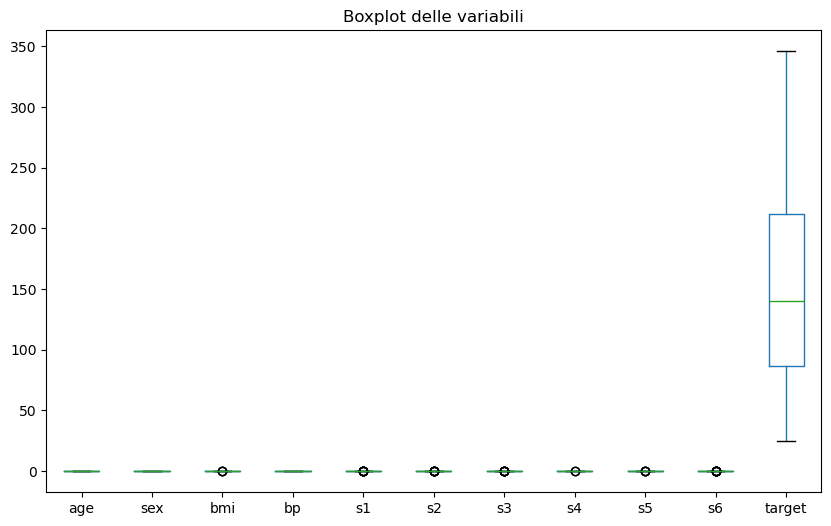

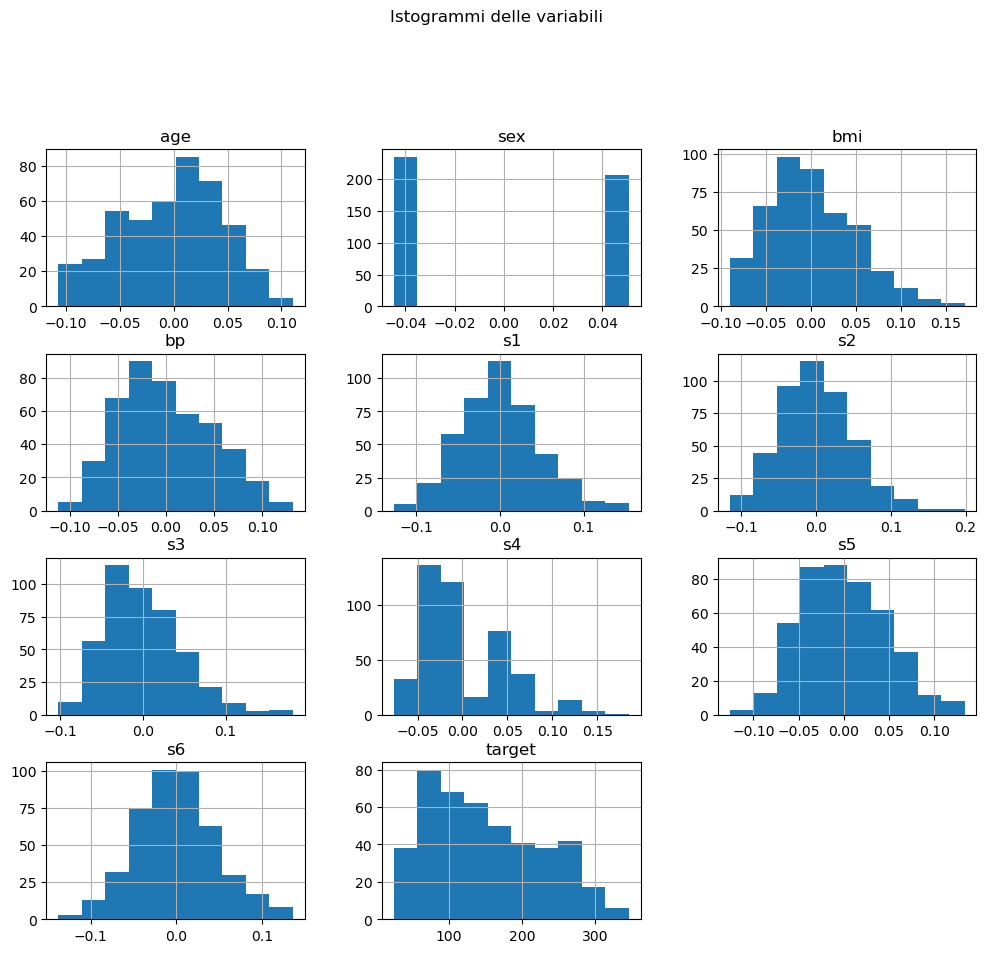

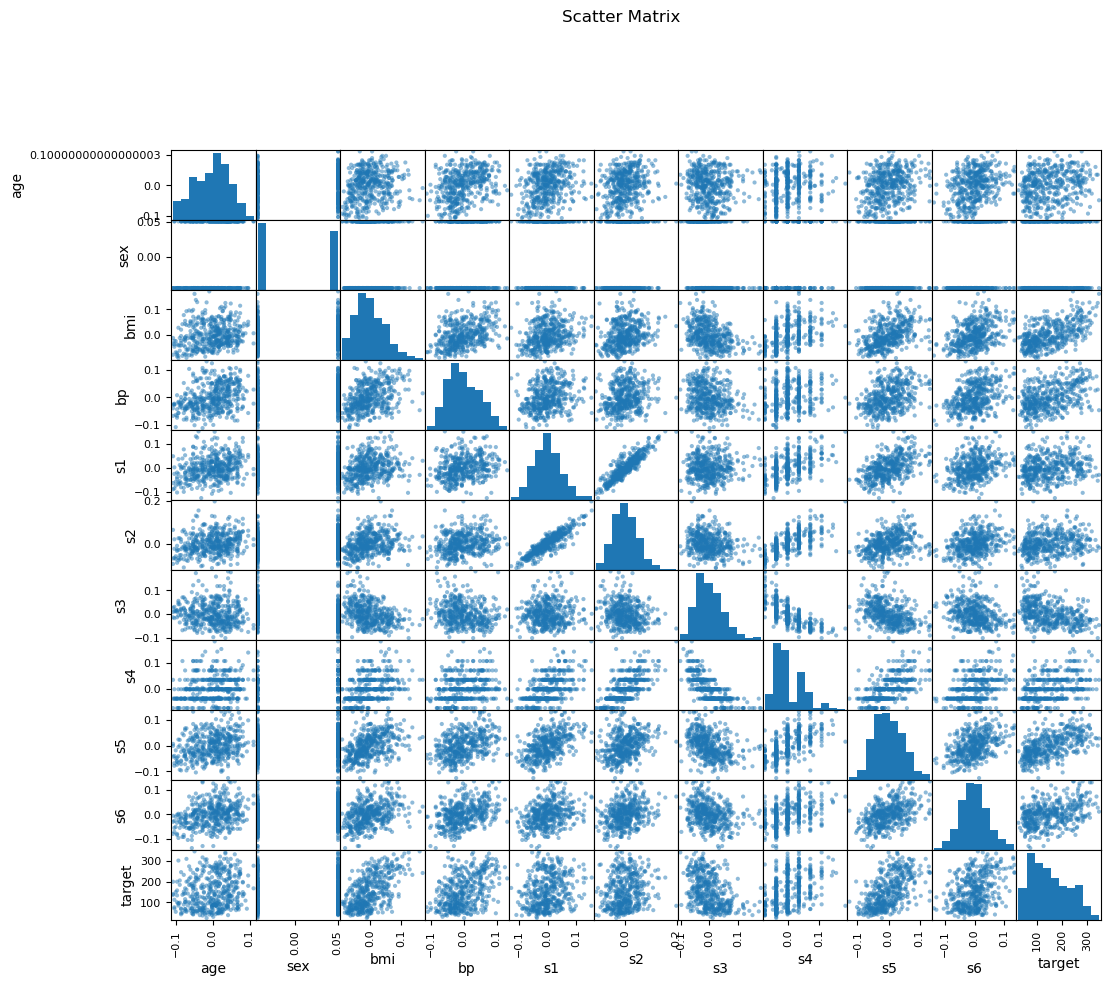

In [98]:
# Boxplot

df.boxplot(figsize=(10, 6), grid=False)
plt.title("Boxplot delle variabili")
plt.show()

# Istogrammi

df.hist(figsize=(12, 10))
plt.suptitle("Istogrammi delle variabili", y=1.02)
plt.show()

# Scatter matrix

scatter_matrix(df, figsize=(12, 10), diagonal='hist')
plt.suptitle("Scatter Matrix", y=1.02)
plt.show()

E — Train/Test split:

Divide
80% training
20% test

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

F — Definizione modelli : Crea l’elenco dei modelli da confrontare

In [100]:
models = [
    ("Linear", LinearRegression()),
    ("Tree", DecisionTreeRegressor(random_state=42)),
    ("Ridge", Ridge()),
    ("Lasso", Lasso(max_iter=5000)),
    ("KNN", KNeighborsRegressor()),
    ("SVR", SVR())
]

G — Cross-validation con Negative MSE:

Per ogni modello:
applica K-Fold CV
valuta il neg_mean_squared_error

NMSE più alto = meglio

In [101]:
results = []
names = []

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models:
    cv_results = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring='neg_mean_squared_error'
    )

    results.append(cv_results)
    names.append(name)

    print(f"{name}")
    print(f"  NMSE medio: {cv_results.mean():.3f}")
    print(f"  STD:        {cv_results.std():.3f}")
    print(f"  MSE medio:  {-cv_results.mean():.3f}\n")

Linear
  NMSE medio: -3067.309
  STD:        548.767
  MSE medio:  3067.309

Tree
  NMSE medio: -6857.440
  STD:        1173.181
  MSE medio:  6857.440

Ridge
  NMSE medio: -3536.970
  STD:        762.881
  MSE medio:  3536.970

Lasso
  NMSE medio: -3955.773
  STD:        789.991
  MSE medio:  3955.773

KNN
  NMSE medio: -3838.726
  STD:        622.060
  MSE medio:  3838.726

SVR
  NMSE medio: -5222.154
  STD:        1231.533
  MSE medio:  5222.154



H — Boxplot confronto

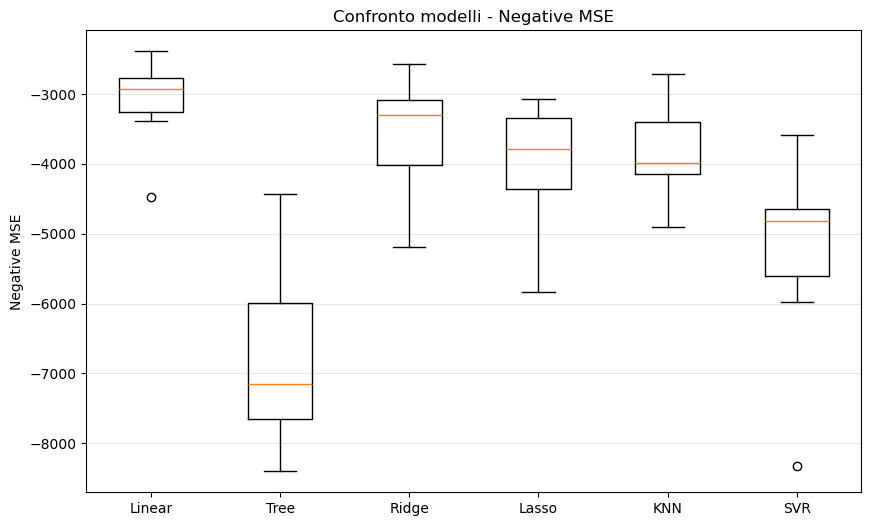

In [102]:
plt.figure(figsize=(10, 6))
plt.boxplot(results, tick_labels=names)
plt.title("Confronto modelli - Negative MSE")
plt.ylabel("Negative MSE")
plt.grid(axis='y', alpha=0.3)
plt.show()

I — Grid Search su Ridge: 

Cerca il miglior valore di alpha per Ridge.

In [103]:
param_grid = {
    "alpha": np.logspace(-3, 3, 13)
}

grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Migliori parametri:", grid.best_params_)
print("Miglior NMSE medio:", grid.best_score_)
print("Miglior MSE medio:", -grid.best_score_)

Migliori parametri: {'alpha': np.float64(0.1)}
Miglior NMSE medio: -3125.1907746343486
Miglior MSE medio: 3125.1907746343486


L — Valutazione finale su test set: 

Metriche
MSE: errore quadratico medio, più basso = meglio
R²: quota di varianza spiegata, più alto = meglio

In [104]:
best_model = grid.best_estimator_

predictions = best_model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MSE test: {mse:.3f}")
print(f"R2 test:  {r2:.3f}")

MSE test: 2856.487
R2 test:  0.461


M — Learning curve

In [105]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = -np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

N — Grafico learning curve

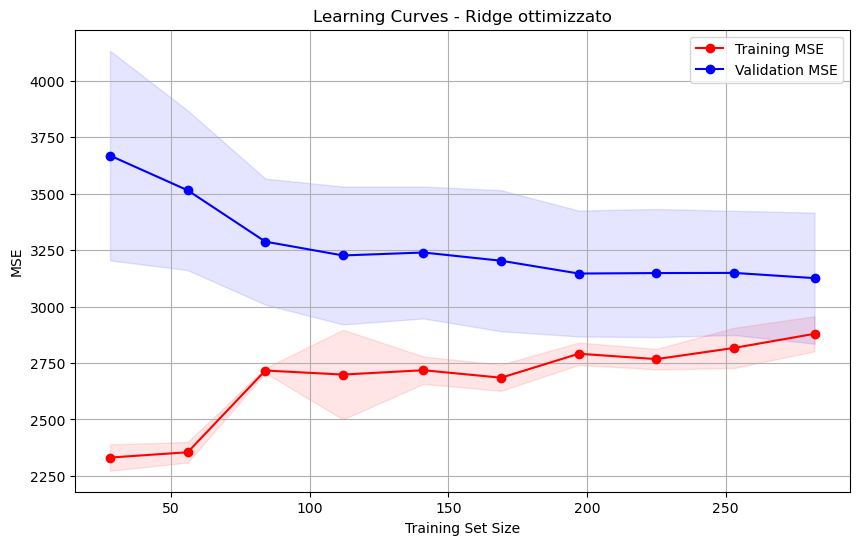

In [106]:
plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, 'o-', color='red', label='Training MSE')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='red')

plt.plot(train_sizes, val_mean, 'o-', color='blue', label='Validation MSE')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='blue')

plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title("Learning Curves - Ridge ottimizzato")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

O - PCA a 2 componenti:

Riduce le 10 feature a:
PC1
PC2

In [107]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

P — Regressione finale nello spazio PCA

In [108]:
best_alpha = grid.best_params_["alpha"]

ridge_pca_model = Ridge(alpha=best_alpha)
ridge_pca_model.fit(X_pca, y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",np.float64(0.1)
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradi

Q — Piano di regressione

In [109]:
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 50),
    np.linspace(y_min, y_max, 50)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
zz = ridge_pca_model.predict(grid_points).reshape(xx.shape)

Scatter 2D dei dati reali

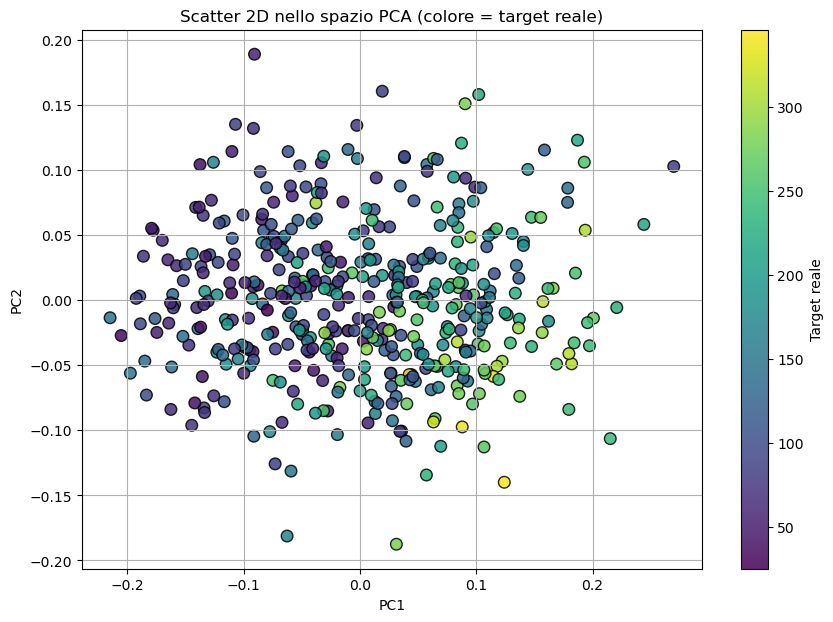

In [110]:
plt.figure(figsize=(10, 7))



scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='viridis',
    s=70,
    edgecolors='k',
    alpha=0.85
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scatter 2D nello spazio PCA (colore = target reale)")
plt.colorbar(scatter, label="Target reale")
plt.grid(True)
plt.show()

Grafico 3D: punti reali + piano di regressione


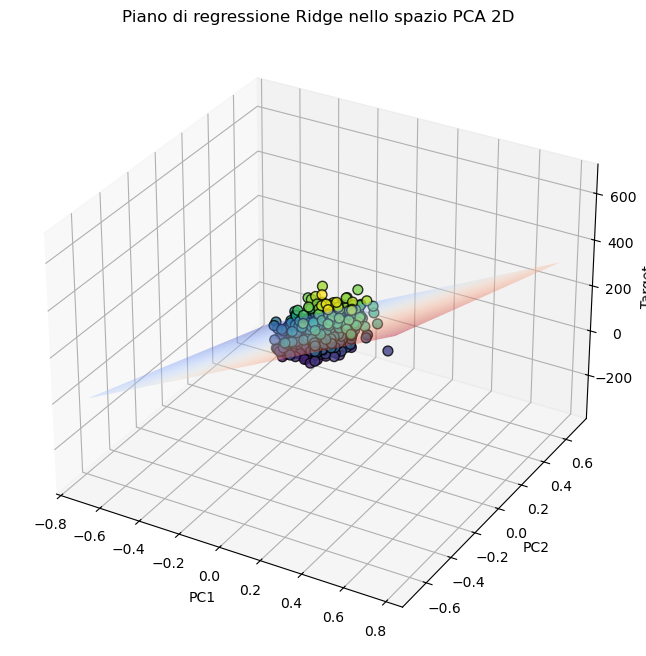

In [111]:
# Grafico 3D: punti reali + piano di regressione
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter dei dati reali nello spazio PCA
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    y,
    c=y,
    cmap='viridis',
    s=50,
    edgecolor='k',
    alpha=0.8
)

# Piano di regressione
ax.plot_surface(
    xx,
    yy,
    zz,
    cmap='coolwarm',
    alpha=0.45,
    linewidth=0
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("Target")
ax.set_title("Piano di regressione Ridge nello spazio PCA 2D")

plt.show()